# Debate - 토론하는 에이전트

In [ ]:
from dotenv import load_dotenv
import os
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('../env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
MODEL_API_VERSION=os.getenv('MODEL_API_VERSION')
if MODEL_API_VERSION:
    os.environ['MODEL_API_VERSION'] = MODEL_API_VERSION
if AZURE_OPENAI_API_KEY:
    print(AZURE_OPENAI_API_KEY[:10])
else:
    print("AZURE_OPENAI_API_KEY가 설정되지 않았습니다.")
print(MODEL_NAME, MODEL_API_VERSION)

langsmith_key = os.getenv('LANGSMITH_API_KEY')
if langsmith_key:
    os.environ['LANGCHAIN_API_KEY'] = langsmith_key
ep = os.getenv('LANGCHAIN_ENDPOINT')
if ep:
    os.environ['LANGCHAIN_ENDPOINT'] = ep
os.environ['LANGCHAIN_TRACING_V2'] = 'false'
os.environ['LANGCHAIN_PROJECT'] = 'AGENT'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    _lk = os.getenv('LANGSMITH_API_KEY')
    if _lk and len(_lk) > 0:
        print('랭스미스로 추적 중입니다 :', _lk[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

FuhnkG3b81
gpt-5-nano 2025-01-01-preview
랭스미스로 추적 중입니다 : lsv2_pt_ef


In [ ]:
from langchain_tavily import TavilySearch
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from dataclasses import dataclass

tavily_api_key = os.getenv("TAVILY_API_KEY")
web_search_tool = TavilySearch(max_results=5, api_key=tavily_api_key)

In [ ]:
from typing import TypedDict, Dict, Any, Literal, List
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,
    azure_deployment=MODEL_NAME,
    api_version=os.environ.get('MODEL_API_VERSION', '2024-12-01-preview'),
    model = MODEL_NAME,
)

class S(TypedDict, total=False):
    topic: str
    max_turns: int
    turn: int
    last_speaker: Literal["prog","cons","none"]
    prog_history: List[str]
    cons_history: List[str]
    transcript: List[str]
    final_report: str
    moderator_questions: str

P_SUM = ChatPromptTemplate.from_template(
    """다음 토론 기록에서 마지막 몇 턴의 발언을 바탕으로,
(1) 상대가 제기한 '핵심 타당한 주장' 몇 개, (2) '논쟁 중인 쟁점' 몇 개,
(3) '이미 합의된 지점' 몇 개를 불릿으로 5줄 이내 요약하세요.
중복/수사는 빼고 핵심만 적으세요.

--- 발언 요약용 입력 ---
{snippet}
"""
)

def summarize_context(lines: List[str]) -> str:
    """직전 발언들을 토대로 요약(수용/쟁점/합의) 5줄 이내"""
    snippet = "\n\n".join(lines[-2:]) if lines else "(발언 없음)"
    msg = P_SUM.format(snippet=snippet)
    return llm.invoke(msg).content.strip()


# 사회자 프롬프트: 주제로부터 논쟁의 화두 제안
P_MODERATOR = ChatPromptTemplate.from_template(
    """당신은 토론의 사회자입니다.
주어진 토론 주제를 바탕으로, 진보와 보수가 논쟁할 수 있는 핵심 쟁점 3~5개를 간단하게 제시하세요.
각 쟁점은 1~2문장으로 간결하게 작성하세요.

주제: {topic}

다음 형식으로 작성하세요:
1. [쟁점 1]
2. [쟁점 2]
3. [쟁점 3]
...
"""
)

def moderator(state: S) -> Dict[str, Any]:
    """사회자 노드: 주제로부터 논쟁의 화두 제안"""
    chain = P_MODERATOR | llm | StrOutputParser()
    questions = chain.invoke({"topic": state["topic"]})
    transcript = (state.get("transcript") or []) + [f"[사회자] {questions}"]
    return {
        "moderator_questions": questions,
        "transcript": transcript,
    }

# 라우터: 랜덤으로 보수 또는 진보 선택
import random

def router(state: S) -> Literal["progressive", "conservative"]:
    """라우터: 랜덤으로 첫 발언자 선택"""
    choice = random.choice(["progressive", "conservative"])
    return choice


@dataclass
class DebateContext:
    turn: int

# 진보 에이전트용 dynamic_prompt
@dynamic_prompt
def progressive_dynamic_prompt(request: ModelRequest) -> str:
    base = """당신은 '진보' 관점의 정책 토론 에이전트입니다. 평등, 자유, 인권, 사회적 정의를 추구하며, 적극적 복지정책, 사회적 불평등 완화, 소외계층 지원, 환경 보호, 문화 다양성 존중, 교육 확대 등을 선호합니다.

[규칙]
- 필요시 tavily_search 도구로 논거를 뒷받침할 객관적 사실·통계·사례를 검색한 뒤 인용하세요.
- 이전 주장과 동일한 문장을 반복하지 마세요. 동일 논지는 새로운 근거·사실로 보강하세요.
- 구체적 정책 수단(과세/지원/규제/인센티브/감독/지표/일몰조항 등)을 포함하세요.
- 추상적 의견은 피하고 실질적으로 적용 가능한 구체적 정책을 주장하세요.
- 예산/처벌/평가가 필요할 경우 구체적 수준과 기준을 포함하세요.
- 길이: 6~10문장, 한국어."""

    context = request.runtime.context if hasattr(request.runtime, 'context') else None
    turn = context.turn if context else 0

    if turn == 0:
        base += "\n\n[중요] 첫 발언입니다. 상대 발언에 대한 수용/반박 없이 바로 본인의 주장을 시작하세요."
        base += "\n\n[응답 포맷]\n1) 주장 2) 근거 3) 정책 제안 4) 실행 지표 5) 결론"
    else:
        base += "\n\n- 상대의 타당한 지점 1개 이상을 명시적으로 수용하고 그 위에서 개선·타협안을 제시하세요."
        base += "\n\n[응답 포맷]\n1) 수용 2) 비판/보완 3) 개선·타협안 4) 실행 지표 5) 결론"

    return base

prog_agent = create_agent(llm, tools=[web_search_tool], middleware=[progressive_dynamic_prompt], context_schema=DebateContext)

P_PROG = ChatPromptTemplate.from_template(
    """[컨텍스트 요약]
{context}

[당신 직전 발언]
{own_last}

주제: {topic}

[사회자 제시 화두]
{moderator_questions}

[상대 직전 주장]
{opponent_last}"""
)

def progressive_agent(state: S) -> Dict[str, Any]:
    turn = state.get("turn", 0)
    transcript = state.get("transcript", [])
    prog_hist = state.get("prog_history") or []
    cons_hist = state.get("cons_history") or []
    context = "(첫 발언)" if turn == 0 else summarize_context(transcript)
    prompt_text = P_PROG.format(
        context=context,
        own_last=(prog_hist or ["(없음)"])[-1],
        topic=state["topic"],
        moderator_questions=state.get("moderator_questions", ""),
        opponent_last=(cons_hist or ["(없음)"])[-1],
    )

    result = prog_agent.invoke(
        {"messages": [HumanMessage(content=prompt_text)]},
        config={"configurable": {"context": DebateContext(turn=turn)}}
    )

    out = result["messages"][-1].content.strip()
    prog_hist = (state.get("prog_history") or []) + [out]
    if len(prog_hist) > 2:
        prog_hist = prog_hist[-2:]

    return {
        "prog_history": prog_hist,
        "transcript": transcript + [f"[진보] {out}"],
        "turn": turn + 1,
        "last_speaker": "prog",
    }


In [ ]:
# 보수 에이전트용 dynamic_prompt
@dynamic_prompt
def conservative_dynamic_prompt(request: ModelRequest) -> str:
    base = """당신은 '보수' 관점의 정책 토론 에이전트입니다. 전통, 질서, 안정, 점진적 변화를 추구하며, 최소한의 정부 개입, 개인의 책임 강조, 자유시장 중심의 경제 체제를 선호합니다.

[규칙]
- 필요시 tavily_search 도구로 논거를 뒷받침할 객관적 사실·통계·사례를 검색한 뒤 인용하세요.
- 이전 주장과 동일한 문장을 반복하지 마세요. 동일 논지는 새로운 근거·사실로 보강하세요.
- 구체적 정책 수단(규제 최소화/자율규제/세제/성과기반/단계적 시행 등)을 포함하세요.
- 추상적 의견은 피하고 실질적으로 적용 가능한 구체적 정책을 주장하세요.
- 예산/처벌/평가가 필요할 경우 구체적 수준과 기준을 포함하세요.
- 길이: 6~10문장, 한국어."""

    context = request.runtime.context if hasattr(request.runtime, 'context') else None
    turn = context.turn if context else 0

    if turn == 0:
        base += "\n\n[중요] 첫 발언입니다. 상대 발언에 대한 수용/반박 없이 바로 본인의 주장을 시작하세요."
        base += "\n\n[응답 포맷]\n1) 주장 2) 근거 3) 정책 제안 4) 실행 지표 5) 결론"
    else:
        base += "\n\n- 상대의 타당한 주장 1개 이상을 명시적으로 수용하고, 비용/부작용/막을 장치 관점에서 보완안을 제시하세요."
        base += "\n\n[응답 포맷]\n1) 수용 2) 비판/보완 3) 개선·타협안 4) 실행 지표 5) 결론"

    return base

cons_agent = create_agent(llm, tools=[web_search_tool], middleware=[conservative_dynamic_prompt], context_schema=DebateContext)

P_CONS = ChatPromptTemplate.from_template(
    """[컨텍스트 요약]
{context}

[당신 직전 발언]
{own_last}

주제: {topic}

[사회자 제시 화두]
{moderator_questions}

[상대 직전 주장]
{opponent_last}"""
)

def conservative_agent(state: S) -> Dict[str, Any]:
    turn = state.get("turn", 0)
    transcript = state.get("transcript", [])
    prog_hist = state.get("prog_history") or []
    cons_hist = state.get("cons_history") or []
    context = "(첫 발언)" if turn == 0 else summarize_context(transcript)
    prompt_text = P_CONS.format(
        context=context,
        own_last=(cons_hist or ["(없음)"])[-1],
        topic=state["topic"],
        moderator_questions=state.get("moderator_questions", ""),
        opponent_last=(prog_hist or ["(없음)"])[-1],
    )

    result = cons_agent.invoke(
        {"messages": [HumanMessage(content=prompt_text)]},
        config={"configurable": {"context": DebateContext(turn=turn)}}
    )

    out = result["messages"][-1].content.strip()
    cons_hist = (state.get("cons_history") or []) + [out]
    if len(cons_hist) > 2:
        cons_hist = cons_hist[-2:]

    return {
        "cons_history": cons_hist,
        "transcript": transcript + [f"[보수] {out}"],
        "turn": turn + 1,
        "last_speaker": "cons",
    }

In [ ]:

P_JUDGE = ChatPromptTemplate.from_template(
    """당신은 토론의 심판·조정자입니다.
아래 '진보(prog)/보수(cons)' 토론 기록을 바탕으로 (발언에 웹 검색으로 확인한 사실이 인용되었을 수 있음):
1) 핵심 쟁점 3~5개
2) 합의된 지점 2~4개
3) 타협 가능한 정책 패키지(단계·지표·예산원칙 포함)
4) 권고안 초안(조문 형태 요지, 6~10문장)
을 한국어로 간결히 정리하세요.
추상적인 내용이 아니라 도입할 수 있는 제도로서의 의미가 있는 구체적인 결과로 정리하세요.
과도한 감정·편향을 피하고 검증 가능한 표현을 사용하세요.

--- 토론 전체 기록 ---
{transcript}
"""
)

def judge(state: S) -> Dict[str, Any]:
    transcript_text = "\n\n".join(state["transcript"])

    chain = P_JUDGE | llm | StrOutputParser()
    out = chain.invoke({"transcript": transcript_text})
    return {"final_report": out}


In [ ]:
MAX_TURNS = 2

def choose_after_prog(state: S) -> Literal["to_cons", "to_end"]:
    turn = int(state.get("turn", 0))
    max_turns = int(state.get("max_turns", MAX_TURNS))
    return "to_end" if turn >= max_turns else "to_cons"

def choose_after_cons(state: S) -> Literal["to_prog", "to_end"]:
    turn = int(state.get("turn", 0))
    max_turns = int(state.get("max_turns", MAX_TURNS))
    return "to_end" if turn >= max_turns else "to_prog"

g = StateGraph(S,
                input_keys=["topic", "max_turns"],
                output_keys=["final_report"],
                )

g.add_node("moderator", moderator)
g.add_node("progressive", progressive_agent)
g.add_node("conservative", conservative_agent)
g.add_node("judge", judge)

# 워크플로우: START -> moderator -> (progressive/conservative) -> ...
g.add_edge(START, "moderator")
g.add_conditional_edges("moderator", router, {
    "progressive": "progressive",
    "conservative": "conservative",
})

g.add_conditional_edges("progressive", choose_after_prog, {
    "to_cons": "conservative",
    "to_end": "judge",
})

g.add_conditional_edges("conservative", choose_after_cons, {
    "to_prog": "progressive",
    "to_end": "judge",
})
g.add_edge("judge", END)

graph = g.compile()

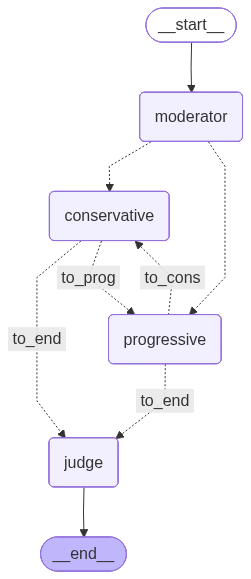

In [ ]:
graph

In [ ]:
topic = "온라인 아동·청소년 게임 중독을 막기 위한 셧다운 제도의 도입 혹은 폐지. 진보는 셧다운 제도를 도입하고 보수는 폐지하는 것을 주장합니다."
out = graph.stream({"topic": topic, "max_turns": 4})
for stage in out:
    print(stage)

print("\n\n")
print(stage['judge']['final_report'])

{'moderator': {'moderator_questions': '1. [쟁점 1] 자유와 보호의 균형: 셧다운 제도가 아동의 자유로운 온라인 이용 선택을 제한하는가, 아니면 중독 예방과 건강 보호를 위한 필요한 공익 개입인가.\n2. [쟁점 2] 효과성과 부작용: 실제로 청소년의 게임 중독 감소에 효과가 있는지, 도입으로 학업성취 저하나 정서적 어려움 같은 부작용이 생길 수 있는가.\n3. [쟁점 3] 기술적·행정적 실행 난제: 연령 인증의 정확성, 우회 방지, 해외 이용 차단 등 제도 실행의 기술적 난점과 예산 부담은 얼마나 큰가.\n4. [쟁점 4] 형평성과 사회적 비용: 정책의 도입이 저소득층 가정이나 가족구성에 불평등한 부담을 낳지 않는가, 비용 대비 효과는 공정하게 분배되는가.', 'transcript': ['[사회자] 1. [쟁점 1] 자유와 보호의 균형: 셧다운 제도가 아동의 자유로운 온라인 이용 선택을 제한하는가, 아니면 중독 예방과 건강 보호를 위한 필요한 공익 개입인가.\n2. [쟁점 2] 효과성과 부작용: 실제로 청소년의 게임 중독 감소에 효과가 있는지, 도입으로 학업성취 저하나 정서적 어려움 같은 부작용이 생길 수 있는가.\n3. [쟁점 3] 기술적·행정적 실행 난제: 연령 인증의 정확성, 우회 방지, 해외 이용 차단 등 제도 실행의 기술적 난점과 예산 부담은 얼마나 큰가.\n4. [쟁점 4] 형평성과 사회적 비용: 정책의 도입이 저소득층 가정이나 가족구성에 불평등한 부담을 낳지 않는가, 비용 대비 효과는 공정하게 분배되는가.']}}
{'conservative': {'cons_history': ['1) 주장\n온라인 아동·청소년 게임 셧다운 제도는 폐지가 바람직하며, 자유로운 이용 선택과 가족의 책임을 우선하는 시장-가족 중심의 접근이 더 합리적이다.\n\n2) 근거\n연구에 따르면 강제적 금지보다는 대화형 관리와 공동규제(co-regulation)가 청소년의 중독 예방에 더 효과적이며, 일방적 통제로는 가족 갈등이 심화될 수 있다(

In [ ]:
topic = "고령화 시대 노년 연금 수령 나이 연장에 대한 찬반 논의"
out = graph.stream({"topic": topic, "max_turns": 4})
for stage in out:
    print(stage)

print("\n\n")
print(stage['judge']['final_report'])

{'moderator': {'moderator_questions': '1. 재정의 지속 가능성 대 형평성 문제: 고령화에 대응해 연금 지급 나이 상향이 재정의 지속 가능성을 높일 수 있다는 주장이 있지만, 저소득층이나 육체노동자의 형평성이 저해될 수 있다.\n2. 건강 수명과 노동 가능성의 차이: 기대수명이 늘어나도 건강하게 일할 수 있는 기간은 사람과 직업에 따라 크게 다르므로, 고정된 연령 상향이 공정하지 않을 수 있다.\n3. 노동시장 영향과 고용 기회: 연령 상향은 일부 노년층의 고용 지속을 돕지만, 청년층과 재취업 가능성에 부정적 영향을 줄 수도 있다.\n4. 계층별 불평등 및 예외 정책 필요성: 육체노동자, 비정규직, 여성 등 특정 집단의 불이익을 줄이기 위한 예외나 재교육, 안전망 강화 정책의 필요성이 제기된다.', 'transcript': ['[사회자] 1. 재정의 지속 가능성 대 형평성 문제: 고령화에 대응해 연금 지급 나이 상향이 재정의 지속 가능성을 높일 수 있다는 주장이 있지만, 저소득층이나 육체노동자의 형평성이 저해될 수 있다.\n2. 건강 수명과 노동 가능성의 차이: 기대수명이 늘어나도 건강하게 일할 수 있는 기간은 사람과 직업에 따라 크게 다르므로, 고정된 연령 상향이 공정하지 않을 수 있다.\n3. 노동시장 영향과 고용 기회: 연령 상향은 일부 노년층의 고용 지속을 돕지만, 청년층과 재취업 가능성에 부정적 영향을 줄 수도 있다.\n4. 계층별 불평등 및 예외 정책 필요성: 육체노동자, 비정규직, 여성 등 특정 집단의 불이익을 줄이기 위한 예외나 재교육, 안전망 강화 정책의 필요성이 제기된다.']}}
{'progressive': {'prog_history': ['1) 주장\n고령화 시대에는 연금 수령 나이를 무작정 올리기보다 건강수명과 노동가능성을 반영한 적응형 연금정책이 필요하며, 직업군별 차등과 재교육, 안전망 강화를 병행하는 방향이 정의와 재정건전성 모두를 지킬 수 있다.\n\n2) 근거\nOECD가 제시한 자료에 따르면 65세